***TELCO CUSTOMER CHURN***





VARSHNI A

---------- **Phase 1: Pandas Fundamentals** ----------

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
import pandas as pd
import io

# This looks for the file name you just uploaded
file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

if file_name in uploaded:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print("✅ File successfully loaded into 'df'!")

else:
    print("❌ Upload failed or filename doesn't match.")

✅ File successfully loaded into 'df'!


 **1. Structural Inspection**

In [ ]:
# 1.1 The "Passport" of your data (Columns, non-null counts, and types)
print("--- DATA OVERVIEW ---")
df.info()

# 1.2 View specific dimensions
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")

# 1.3 List all column names (helpful for big datasets)
print("\n--- COLUMN LIST ---")
print(df.columns.tolist())

--- DATA OVERVIEW ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

**2. The "Deep Dive" Statistics**

In [ ]:
# 2.1 Summary of numerical columns (Mean, Max, Standard Deviation)
print("\n--- STATISTICAL SUMMARY ---")
print(df.describe())

# 2.2 Summary of categorical (text) columns
print("\n--- CATEGORICAL SUMMARY ---")
print(df.describe(include='object'))


--- STATISTICAL SUMMARY ---
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000

--- CATEGORICAL SUMMARY ---
        customerID gender Partner Dependents PhoneService MultipleLines  \
count         7043   7043    7043       7043         7043          7043   
unique        7043      2       2          2            2             3   
top     3186-AJIEK   Male      No         No          Yes            No   
freq             1   3555    3641       4933         6361          3390   

       InternetService OnlineSecurity OnlineBackup DeviceProtection  \
count             7043           7043        

**3. Data Cleaning & Type Correction**

In [ ]:
# 3.1 Identify empty strings and convert to NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3.2 Check how many missing values exist now
print(f"\nMissing TotalCharges: {df['TotalCharges'].isnull().sum()}")

# 3.3 Fill missing values with the median (best practice for money/charges)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 3.4 Drop the 'customerID' column (it doesn't help with patterns)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)


Missing TotalCharges: 11


/tmp/ipykernel_6666/2589421271.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


**4. Slicing and Filtering (The "Query" Phase)**

In [ ]:
# 4.1 Filter: Find only customers with Fiber Optic who stayed
high_tech_loyal = df[(df['InternetService'] == 'Fiber optic') & (df['Churn'] == 'No')]
print(f"\nNumber of Loyal Fiber Optic Users: {len(high_tech_loyal)}")

# 4.2 Grouping: Which Contract type pays the most on average?
#
avg_payment = df.groupby('Contract')['MonthlyCharges'].mean()
print("\n--- AVERAGE MONTHLY CHARGES PER CONTRACT ---")
print(avg_payment)


Number of Loyal Fiber Optic Users: 1799

--- AVERAGE MONTHLY CHARGES PER CONTRACT ---
Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64


**5. Categorical Logic**

In [ ]:
# 5.1 Percentage of Churn (Is the data balanced?)
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print("\n--- CHURN PERCENTAGE ---")
print(f"Stayed: {churn_rate['No']:.2f}%")
print(f"Left: {churn_rate['Yes']:.2f}%")


--- CHURN PERCENTAGE ---
Stayed: 73.46%
Left: 26.54%


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


--------- **Phase 2: Exploratory Data Analysis (EDA)** ---------


**1. The Global View (Target Distribution)**

/tmp/ipykernel_6666/2933893913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


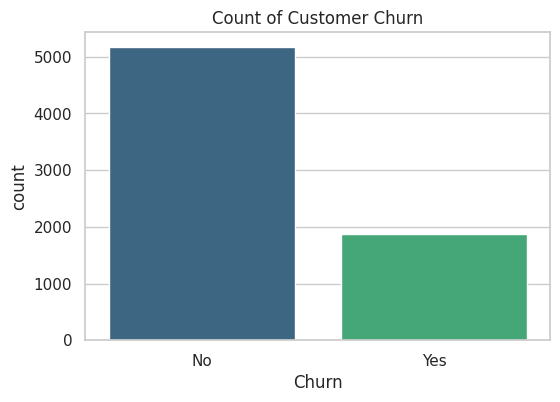

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Count of Customer Churn')
plt.show()

**2. The Business Driver: Contract Type**

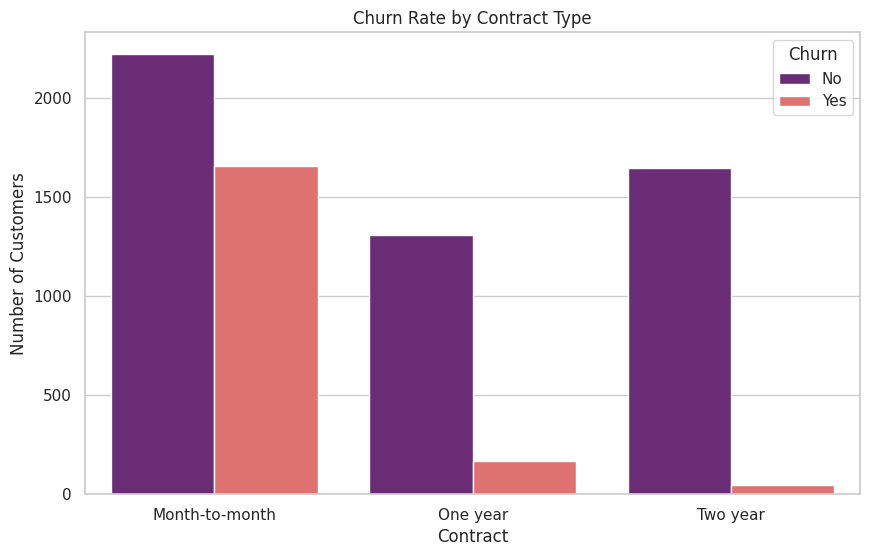

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Number of Customers')
plt.show()

**3. Numerical Relationships: Tenure vs. Monthly Charges**

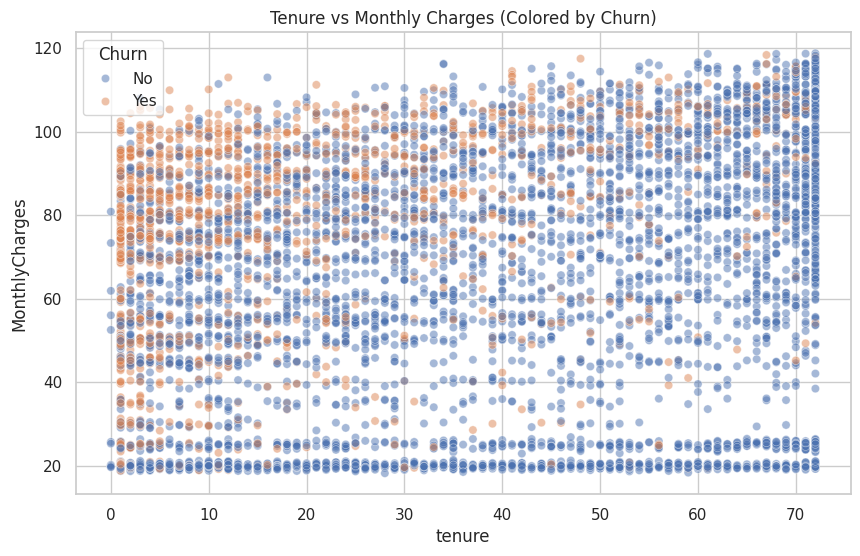

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.5)
plt.title('Tenure vs Monthly Charges (Colored by Churn)')
plt.show()

**4. The Correlation Heatmap**

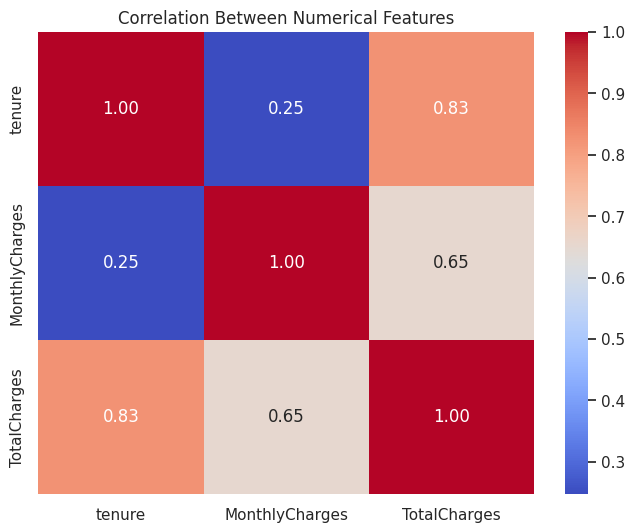

In [ ]:
# We only use numerical columns for the correlation matrix
plt.figure(figsize=(8, 6))
correlation_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numerical Features')
plt.show()

----------**Phase 3: Machine Learning** ----------

**1. Feature Engineering (Encoding)**

In [ ]:
# Convert text to binary numbers (0 and 1)
# 'drop_first=True' prevents redundant data (e.g., we don't need 'Male' and 'Female' columns, just 'Is_Male')
df_ml = pd.get_dummies(df, drop_first=True)

print("New columns created:")
print(df_ml.columns[:10]) # Looking at the first 10 new column names

New columns created:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes'],
      dtype='object')


**2. Splitting the Data**

In [ ]:
from sklearn.model_selection import train_test_split

# X = Everything EXCEPT the thing we want to predict (Churn)
X = df_ml.drop('Churn_Yes', axis=1)

# y = Only the Churn column
y = df_ml['Churn_Yes']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 5634 rows
Testing set size: 1409 rows


**3. Training the Model (The Brain)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


**4. Scoring & Evaluation**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the hidden test set
predictions = model.predict(X_test)

print(f"Overall Accuracy: {accuracy_score(y_test, predictions):.2%}")
print("\n--- Detailed Report ---")
print(classification_report(y_test, predictions))

Overall Accuracy: 81.41%

--- Detailed Report ---
              precision    recall  f1-score   support

       False       0.84      0.92      0.88      1036
        True       0.70      0.53      0.60       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



**5. Prediction**

In [ ]:
import pandas as pd
import numpy as np

# 1. Create a "New Customer" profile
# Let's imagine a customer who is on a Month-to-month contract with Fiber Optic
new_customer_data = {
    'tenure': [2],                # New customer (2 months)
    'MonthlyCharges': [95.50],     # High monthly bill
    'TotalCharges': [191.00],      # 2 months * 95.50
    'SeniorCitizen': [0],
    'Contract': ['Month-to-month'],
    'InternetService': ['Fiber optic'],
    'TechSupport': ['No'],
    'PaperlessBilling': ['Yes'],
    # ... we'll let pd.get_dummies handle the rest of the categories
}

# 2. Turn this into a DataFrame
new_df = pd.DataFrame(new_customer_data)

# 3. Match the format of your training data
# We need to apply the same get_dummies we used on the training set
new_df_encoded = pd.get_dummies(new_df).reindex(columns=X.columns, fill_value=0)

# 4. Make the Prediction
prediction = model.predict(new_df_encoded)
probability = model.predict_proba(new_df_encoded)[0][1]

# 5. Output the result
print("--- PREDICTION RESULT ---")
if prediction[0] == 1:
    print(f"Status: LIKELY TO CHURN (Probability: {probability:.2%})")
    print("Action: Offer this customer a long-term discount immediately!")
else:
    print(f"Status: LIKELY TO STAY (Probability: {probability:.2%})")

--- PREDICTION RESULT ---
Status: LIKELY TO CHURN (Probability: 74.56%)
Action: Offer this customer a long-term discount immediately!


In [ ]:
import pandas as pd
import numpy as np

# 1. Create a "New Customer" profile
# Let's imagine a customer who is on a Month-to-month contract with Fiber Optic
new_customer_data = {
    'tenure': [72],                # New customer (2 months)
    'MonthlyCharges': [95.50],     # High monthly bill
    'TotalCharges': [191.00],      # 2 months * 95.50
    'SeniorCitizen': [0],
    'Contract': ['Two year'],
    'InternetService': ['Fiber optic'],
    'TechSupport': ['No'],
    'PaperlessBilling': ['Yes'],
    # ... we'll let pd.get_dummies handle the rest of the categories
}

# 2. Turn this into a DataFrame
new_df = pd.DataFrame(new_customer_data)

# 3. Match the format of your training data
# We need to apply the same get_dummies we used on the training set
new_df_encoded = pd.get_dummies(new_df).reindex(columns=X.columns, fill_value=0)

# 4. Make the Prediction
prediction = model.predict(new_df_encoded)
probability = model.predict_proba(new_df_encoded)[0][1]

# 5. Output the result
print("--- PREDICTION RESULT ---")
if prediction[0] == 1:
    print(f"Status: LIKELY TO CHURN (Probability: {probability:.2%})")
    print("Action: Offer this customer a long-term discount immediately!")
else:
    print(f"Status: LIKELY TO STAY (Probability: {probability:.2%})")

--- PREDICTION RESULT ---
Status: LIKELY TO STAY (Probability: 26.45%)


---------- **Phase 4: Streamlit**---------

**1. The "Save" Step**

In [ ]:
import pickle

# This saves the 'brain' of your AI
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# This saves the list of column names (the 'labels')
with open('columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Files saved successfully!")
print("Step 1 Complete: Your model files are ready!")

Files saved successfully!
Step 1 Complete: Your model files are ready!




**2. The "App" Step**

In [41]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle

# Load the brain
model = pickle.load(open('churn_model.pkl', 'rb'))
cols = pickle.load(open('columns.pkl', 'rb'))

st.title("📊 Customer Churn Predictor")

# Input Fields
tenure = st.number_input("Months stayed with company", 0, 72, 12)
contract = st.selectbox("Contract Type", ['Month-to-month', 'One year', 'Two year'])
internet = st.selectbox("Internet Service Type", ['DSL', 'Fiber optic', 'No']) # Added this!
monthly = st.number_input("Monthly Bill ($)", 0, 200, 70)

if st.button("Predict"):
    # Create a tiny table for the prediction
    df_input = pd.DataFrame(columns=cols)
    df_input.loc[0] = 0

    # Fill in the basics
    df_input['tenure'] = tenure
    df_input['MonthlyCharges'] = monthly

    # Fill in the categories (Logic to match your 81% model)
    if f"Contract_{contract}" in df_input.columns:
        df_input[f"Contract_{contract}"] = 1
    if f"InternetService_{internet}" in df_input.columns:
        df_input[f"InternetService_{internet}"] = 1

    # Make the prediction
    prediction = model.predict(df_input)[0]

    if prediction == 1:
        st.error("⚠️ HIGH RISK: This customer is likely to CHURN.")
    else:
        st.success("✅ LOW RISK: This customer is likely to STAY.")

Overwriting app.py


**3. The "View" Step**

In [44]:
# 1. Get the password for the website
print("YOUR PASSWORD (IP Address):")
!curl ipv4.icanhazip.com

# 2. Start the website and create a link
!npx localtunnel --port 8501 & streamlit run app.py &

YOUR PASSWORD (IP Address):
35.237.245.58
⠙⠹⠸⠼

⠴⠦⠧⠇your url is: https://funny-guests-poke.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.245.58:8501

  Stopping...
